In [1]:
import os

train_path='Cars Dataset/train'
test_path="Cars Dataset/test"

print(os.listdir(train_path)[:5])

['Audi', 'Hyundai Creta', 'Mahindra Scorpio', 'Rolls Royce', 'Swift']


In [3]:
import numpy as np
from PIL import Image

images=[]
train_path = "Cars Dataset/train"

for folder in os.listdir(train_path):

    folder_path = os.path.join(
        train_path,
        folder
    )

    for file in os.listdir(folder_path):

        image_path = os.path.join(
            folder_path,
            file
        )

        try:

            img = Image.open(
                image_path
            )

            img = img.convert(
                "L"
            )

            img = img.resize(
                (64, 64)
            )

            img = np.array(
                img
            )

            images.append(
                img
            )

        except:
            pass

In [4]:
print(
    "Number of Images:",
    len(images)
)

Number of Images: 3352


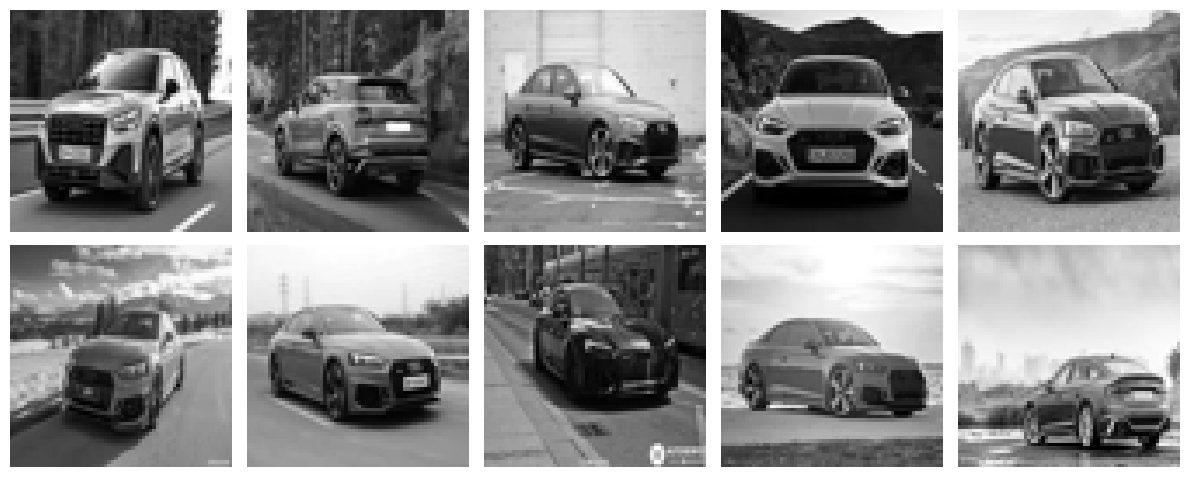

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2, 5,
    figsize=(12, 5)
)

for ax, image in zip(
    axes.ravel(),
    images[:10]
):

    ax.imshow(
        image,
        cmap="gray"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [6]:
X=np.array(images)
print(X.shape)

(3352, 64, 64)


In [7]:
X=X.reshape(
    X.shape[0],-1

)

print(X.shape)

(3352, 4096)


In [8]:
print(X.min())
print(X.max())

0
255


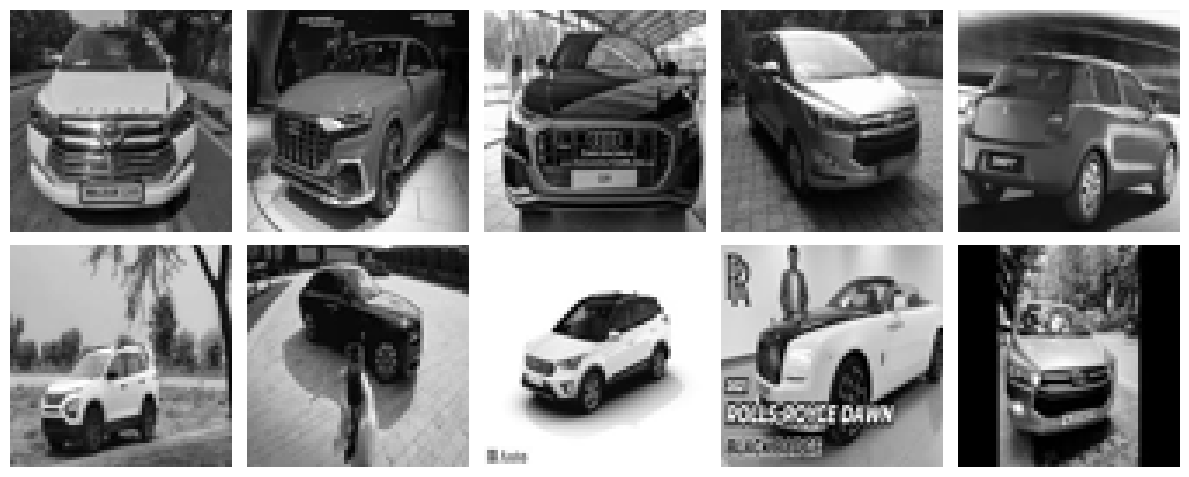

In [9]:
import random

fig, axes = plt.subplots(
    2, 5,
    figsize=(12, 5)
)

for ax in axes.ravel():

    idx = random.randint(
        0,
        len(images)-1
    )

    ax.imshow(
        images[idx],
        cmap="gray"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [10]:
X=X / 255.0

print(X.min())
print(X.max())

0.0
1.0


In [31]:
from sklearn.decomposition import NMF

model=NMF(
    n_components=10,random_state=0,max_iter=1000
)

X_nmf=model.fit_transform(X)

In [32]:
print(X_nmf.shape)

(3352, 10)


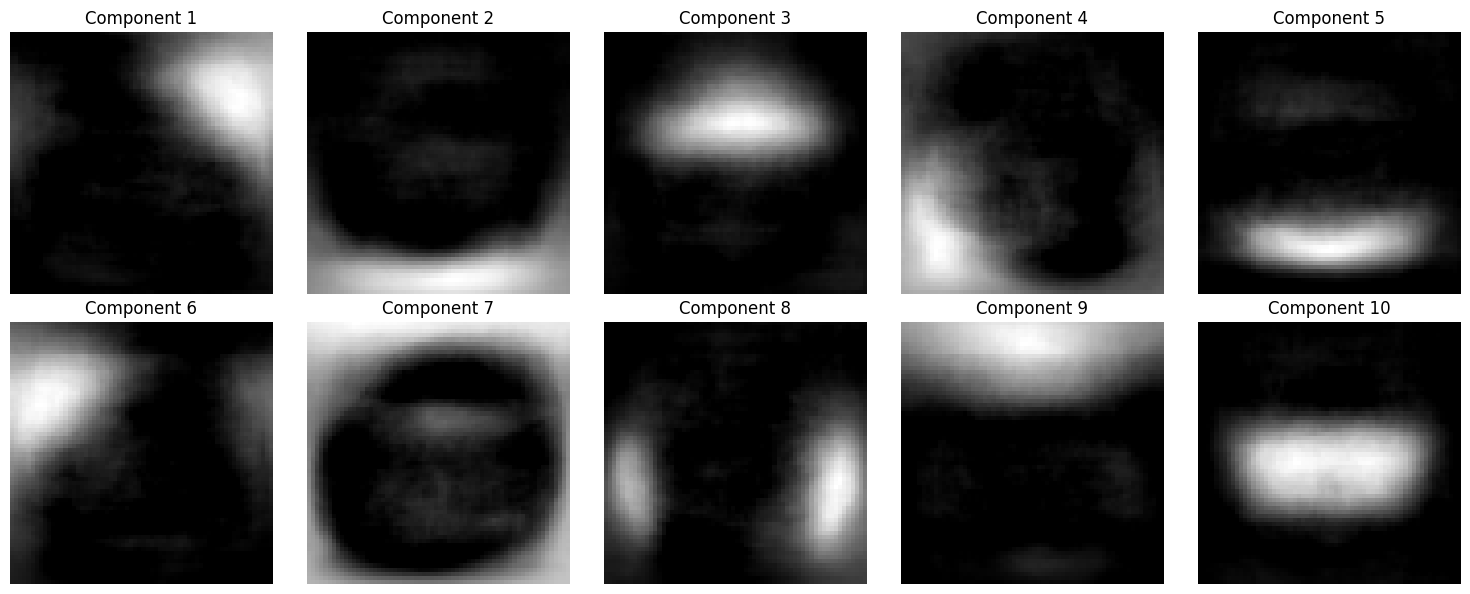

In [36]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(
    2, 5,
    figsize=(15, 6)
)

for i, ax in enumerate(axes.ravel()):

    component = model.components_[i]

    # Scale component values between 0 and 1
    component = (
        component - component.min()
    ) / (
        component.max() - component.min()
    )

    ax.imshow(
        component.reshape(64, 64),
        cmap="gray"
    )

    ax.set_title(
        f"Component {i+1}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()